## 제목: 영동선(서창JC-신갈JC) 교통 데이터 분석  <br>

## (1) 주제 선정 이유: <br>
 나는 인천에서 경희대를 차량으로 통학하면서 영동선(서창-신갈)구간을 지나는데 이 구간에서의 교통정체가 정말 심각하다고 느꼈다. <br>
 
 따라서 영동고속도로의 교통체증에 대한 내 경험에서 비롯한 생각과 실제 데이터 분석 결과가 일치하는 지 궁금해졌다. <br>
 
 또한, 이러한 교통체증의 원인이 무엇일지와 어떠한 요소들이 영동고속도로의 정체에 영향을 미치는지 알아보고자 해당 주제를 선정했다. <br> 

## (2) 가설 정의: <br>
### **<확인점>**  <br>
 1. 영동선 하행에서 차가 가장 막히는 구간은 어디인가? <br>
 
 2. 영동선 상행에서 차가 가장 막히는 구간은 어디인가? <br>
 
 3. 영동선 하행에서 차가 가장 막히는 시간대는 언제인가? <br>
 
 4. 영동선 상행에서 차가 가장 막히는 시간대는 언제인가? <br>
 ### **<명제>** <br>
 1. 영동선 하행에서 출근시간대(오전6시~9시)는 월요일이 가장 차가 막힐 것이다. <br>
 
 2. 영동선 상행에서 퇴근시간대(오후4시~7시)는 금요일이 가장 차가 막힐 것이다. <br>
 
 3. 공휴일과 주말은 평일보다 차가 안 막힐 것이다. <br>
 
 4. 교통이 정체되는 정도는 해당 구간을 통과하는 교통량과 비례할 것이다. <br>

## (3) 인터넷을 통한 데이터 획득: <br>
 경기도 교통정보 센터 - 교통정보 - 영동고속도로 구간별 통계정보 - 10월달(1일~31일) 상행,하행 총 62개의 xlsx파일 다운로드 <br>
 
 경기도 교통정보 센터 - 교통DB - 상시 교통량(고속국도) - 10월달(1일~31일) 상행 1개의 xlsx파일 다운로드 <br>
 
 다만, 분석하고자 하는 xlsx 파일이 한셀 형식으로 되어 있어 Microsoft excel에서 열리지 않는 문제가 발생함. <br>
 
 따라서 Python에서도 이러한 한셀 파일 형식으로 제작된 xlsx파일을 읽어 들일때 Nontype에러가 뜨면서 읽어들이지 못하는 문제가 발생함. <br>
 
 웹 브라우저에서 csv 파일로 변환을 시도해봤으나 폰트가 다 깨져서 불가능 했음. <br>
 
 결국, 전부 수작업으로 한셀파일의 데이터 표를 새로 Microsoft excel 파일에 복사 붙여넣기를 해서 xlsx형태로 저장함 <br> 

## (4) 분석을 위한 데이터의 가공: <br>
 먼저 10월 1일부터 31일에 해당하는 모든 데이터를 상행과 하행을 구별하여 통합해주는 과정을 거쳤다. <br>
 
 이때 os 라이브러리를 불러와서 영동선_10월_상행과 영동선_10월_하행 폴더에 있는 모든 엑셀파일들을 os.listdir() 메소드를 통해 가져왔다.<br>

 os.listdir로 가져온 파일 목록 중에서 .xlsx 확장자로 끝나는 파일만 선택해서 excel_files라는 리스트에 저장했다.<br>

 list의 각 파일의 이름이 숫자로 저장되어 있기에 sorted() 함수를 통해 파일 이름에서 숫자 부분을 추출하여 정수로 변환한 후 그 숫자를 기준으로 1~31 순서대로 파일을 정렬했다.<br>

 이후 파일이름의 숫자를 split() 함수로 읽어들여 통합된 데이터에 '10월'이라는 열을 새로 추가했고 파일이름의 숫자에 해당하는 번호를 할당함으로써 날짜를 구분했다.<br>

 이렇게 통합된 엑셀파일을 다시 불러들여 for 반복문으로 1~31에 해당하는 10월 열의 각 날짜마다 iloc[] 함수를 사용해 포함하고자 하는 구간만을 추출했고 별도의 가공 엑셀파일로 다시 저장했다. <br>

 이렇게 명제4를 제외한 모든 확인점과 명제들에 대해서 최종적으로 가공된 상행과 하행에 대한 엑셀파일을 불러들여서 작업을 했다. <br>

  **<확인점1,2>**  에 대해서는 먼저 mean() 함수를 통해 각 구간별 모든 시간대에 대한 평균속도를 구해줬다. <br>

 그리고 각 날짜별로 가장 막힌 구간을 찾기 위해 for 반복문 안에 idxmin()함수를 사용해 날짜별로 평균속도가 가장 느렸던 구간, 즉, 가장 막힌 구간을 찾았다. <br>

 이후 value_counts()와 idxmax() 함수를 사용해 10월 중 가장 자주 막힌 구간을 찾아내었다. <br>

 그리고 분석결과 도출때 그래프를 그리기 위해 날짜별로 가장 막힌구간을 데이터프레임으로 저장하고 이를 다시 엑셀파일로 저장했다. <br>


 **<확인점3,4>** 에서는 확인점1,2에서와 다르게 시간대별로 평균속도를 구하기 위해 시간대에 해당하는 열만을 time이라는 변수에 iloc[] 함수를 사용해 할당해줬다. <br>

 이후 똑같이 mean()함수로 각 열에 대한 평균값을 구했고 가장 낮은 평균속도의 시간대를 구하기 위하여 먼저 index의 값을 reset_index() 함수를 통해 초기화 한 다음 열의 이름을 시간과 평균속도로 함으로써 보기 좋게 해주었다. <br>

 이후 평균속도 열에 해당하는 값들의 최솟값을 min()함수로 구했고 해당 최솟값을 가지는 행의 첫번째 열, 즉, 시간대를 iloc[0]를 통해 가장 차가 막히는 시간대를 찾았다. <br>

 그리고 분석결과 도출때 그래프를 그리기 위해 시간대별로 평균속도가 적힌 데이터프레임을 별도의 엑셀파일로 저장했다. <br>


 **<명제1,2>** 에서는 각각 출근시간대(06~09시), 퇴근시간대(16~19시)에 해당하는 열을 iloc[]함수로 따로 빼낸다음에 평균속도를 구했다. <br>

 먼저, 2024년 10월 달력에서 월요일에서 일요일까지 해당하는 날짜를 수기로 입력해줬고, 각각의 날짜마다 해당하는 열의 값을 주고 평균값을 구하였다. <br>

 이때 isin() 함수를 통해 각 요일에 포함된 날짜만 필터링할 수 있게 하였고, 평균값은 mean()함수를 통해 구하였다.<br>

 그렇게 각 요일별로 구한 평균속도를 dictionary의 형태로 저장했고 최종적으로 "요일"과 "평균속도" 두 가지의 열을 갖는 데이터프레임의 형태로 저장하였다.<br>

 마찬가지로 별도의 엑셀파일로 저장하였다. <br>


 **<명제3>** 에서는 공휴일, 주말, 평일에 대한 데이터를 상행에서만 추출했다.<br> 

 먼저, 10월달 중 평일과 주말 공휴일에 해당하는 날짜를 각기 다른 변수에 리스트의 형태로 할당해줬고, 이후 명제1,2에서 한 것 처럼 각 리스트에 있는 날짜별로 평균값을 구해줬고 최종적으로 하나의 리스트에 포함된 날짜의 전체 평균값을 구해주기 위해 mean()함수를 한 번 더 사용해줬다.<br>

 그렇게 구한 총 평균값들을 평일, 주말, 공휴일로 구분해 dictionary 형태로 저장했고, "구분"과 "평균속도"라는 두 열을 갖는 데이터 프레임의 형태로 저장하였다.<br> 

 마찬가지로 엑셀파일로도 저장했다.<br>


 **<명제4>** 에서는 교통량.xlsx라는 새로운 데이터를 불러왔고 필요없는 행과 열을 확인점1,2에서와 같이 for 반복문으로 날짜별로 포함하고자 하는 구간만을 iloc[]함수로 지정해줬다.<br>
 
 이후 추가적으로 지우고자 하는 열이나 행을 drop()함수를 이용해 제거해주고 최종적인 데이터프레임을 엑셀파일로 저장해줬다. <br>

 기존에 작업했던 10월_상행_가공 데이터와 교통량_가공 데이터 간에 형식적인 차이가 있어서 이를 일치 시켜주기 위하여 10월_상행_가공 파일의 구간을 drop()함수를 통해 더 줄였다.<br> 
 
 그리고 교통량 원본 데이터를 보니 23일과 24일에 대한 데이터가 유실되어 있어서 똑같이 drop()함수로 해당 날짜의 행을 삭제해줬다.<br>

 이후 확인점4에서 구현했던 코드를 그대로 사용해 가장 평균속도가 낮은 시간대를 구했고, 가공된 교통량 파일에서 mean()함수를 통해 시간대별 교통량 평균값을 구했고 max()함수를 통해 가장 교통량이 많은 시간대를 찾아줬다.<br> 

 따라서 최종적으로 교통량이 가장 많은 시간대와 평균속도가 가장 낮은 시간대가 일치하는지를 print()함수로 출력해 비교해봤다. <br>
 
 마찬가지로 시간대별 교통량과 평균속도를 합친 데이터 프레임을 엑셀파일의 형태로 저장했다.<br>

 **<클래스 작업>** <br>
 
 상기의 막 코딩 단계 이후, 데이터 가공 전체 코드에서 명제4를 제외하면 반복적인 작업이 생겼기에 각각에 맞게 클래스를 생성해줬다. <br>

 그리고 이렇게 생성한 클래스들을 Term_module.py 파일 한 곳에 묶어서 하나의 모듈처럼 활용하였다.<br>

 Term_source_2020104218.ipynb 에서는 Term_module을 import함수로 불러와서 객체를 생성하고, 메소드를 통한 가공을 거친 이후 엑셀파일로 저장하는 작업을 수행해줬다.<br>
 

## (5) 분석 결과 도출: <br>

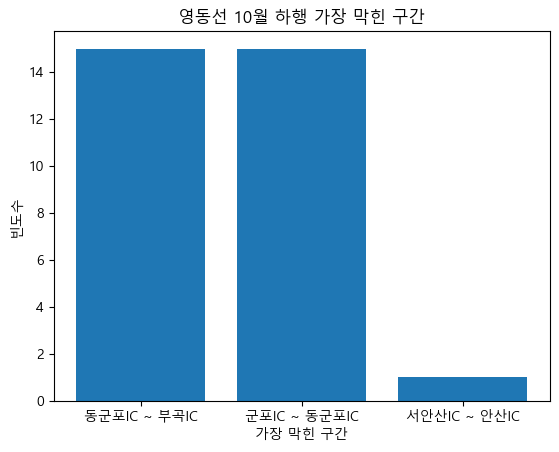

In [10]:
# 확인점 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
df = pd.read_excel('10월_하행_가공\\10월_날짜별_가장 막힌 구간.xlsx')
counts_section = df['가장 막힌 구간'].value_counts().reset_index()
counts_section.columns = ['가장 막힌 구간', '빈도수']
frequency = np.array(counts_section['빈도수'])
most_frequent_section = np.array(counts_section['가장 막힌 구간'])
plt.bar(most_frequent_section, frequency)
plt.title('영동선 10월 하행 가장 막힌 구간')
plt.xlabel('가장 막힌 구간')
plt.ylabel('빈도수')
plt.show()


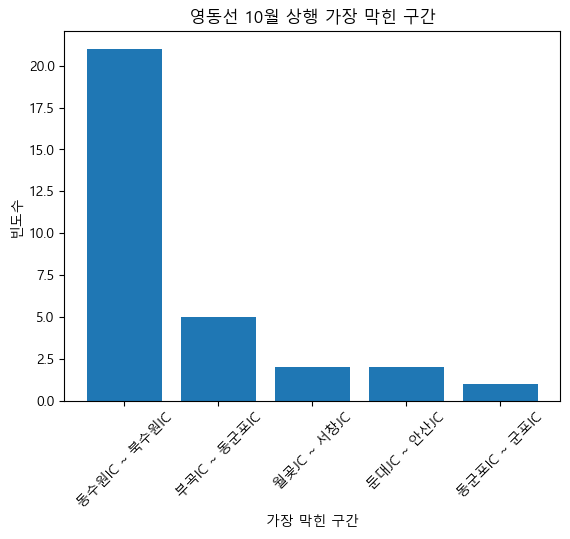

In [11]:
# 확인점 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

df = pd.read_excel('10월_상행_가공\\10월_날짜별_가장 막힌 구간.xlsx')
counts_section = df['가장 막힌 구간'].value_counts().reset_index()
counts_section.columns = ['가장 막힌 구간', '빈도수']
frequency = np.array(counts_section['빈도수'])
most_frequent_section = np.array(counts_section['가장 막힌 구간'])
plt.bar(most_frequent_section, frequency)
plt.title('영동선 10월 상행 가장 막힌 구간')
plt.xlabel('가장 막힌 구간')
plt.ylabel('빈도수')
plt.xticks(rotation=45)
plt.show()

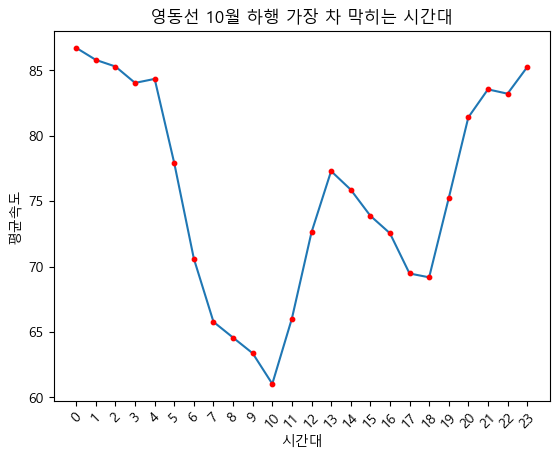

In [12]:
# 확인점 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

df = pd.read_excel('10월_하행_가공\\10월_시간대별_평균속도.xlsx')

time = np.array(df['시간'])
AvgSpeed = np.array(df['평균속도'])
plt.xticks(time, rotation=45)
plt.scatter(time, AvgSpeed, color='red', s= 10, zorder=5)

plt.plot(time, AvgSpeed)
plt.title('영동선 10월 하행 가장 차 막히는 시간대')
plt.xlabel('시간대')
plt.ylabel('평균속도')
plt.show()

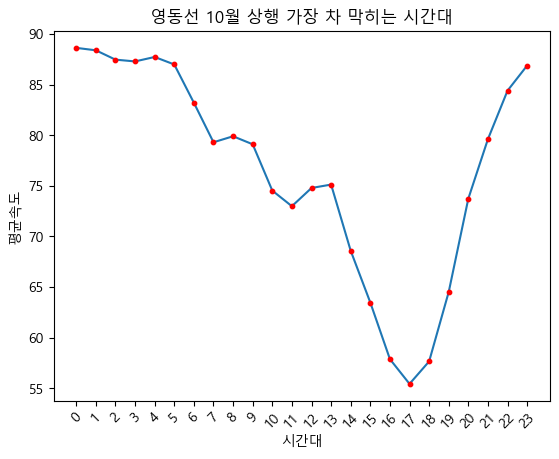

In [13]:
# 확인점 4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

df = pd.read_excel('10월_상행_가공\\10월_시간대별_평균속도.xlsx')

time = np.array(df['시간'])
AvgSpeed = np.array(df['평균속도'])
plt.xticks(time, rotation=45)
plt.scatter(time, AvgSpeed, color='red', s= 10, zorder=5)

plt.plot(time, AvgSpeed)
plt.title('영동선 10월 상행 가장 차 막히는 시간대')
plt.xlabel('시간대')
plt.ylabel('평균속도')
plt.show()

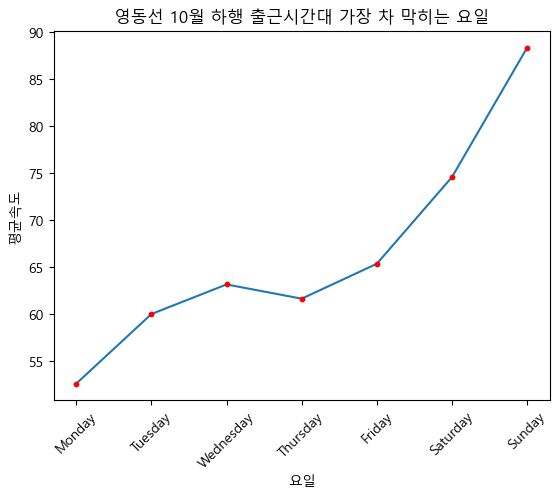

In [14]:
# <명제1> 하행 출근시간대(오전6시~9시) 월요일이 가장 차가 막힐 것이다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

df = pd.read_excel('10월_하행_가공\\10월_요일별_출근시간.xlsx')

AvgSpeed = np.array(df['평균속도'])
Week = np.array(df['요일'])
plt.plot(Week, AvgSpeed)
plt.title('영동선 10월 하행 출근시간대 가장 차 막히는 요일')
plt.xlabel('요일')
plt.ylabel('평균속도')
plt.scatter(Week, AvgSpeed, color='red', s= 10, zorder=5)
plt.xticks(rotation=45)
plt.show()

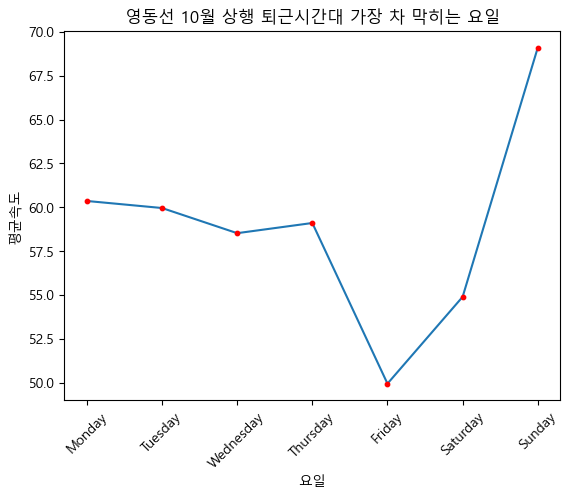

In [15]:
# <명제2> 상행 퇴근시간대(오후4시~7시) 금요일이 가장 차가 막힐 것이다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

df = pd.read_excel('10월_상행_가공\\10월_요일별_퇴근시간대.xlsx')

AvgSpeed = np.array(df['평균속도'])
Week = np.array(df['요일'])
plt.plot(Week, AvgSpeed)
plt.title('영동선 10월 상행 퇴근시간대 가장 차 막히는 요일')
plt.xlabel('요일')
plt.ylabel('평균속도')
plt.scatter(Week, AvgSpeed, color='red', s= 10, zorder=5)
plt.xticks(rotation=45)
plt.show()

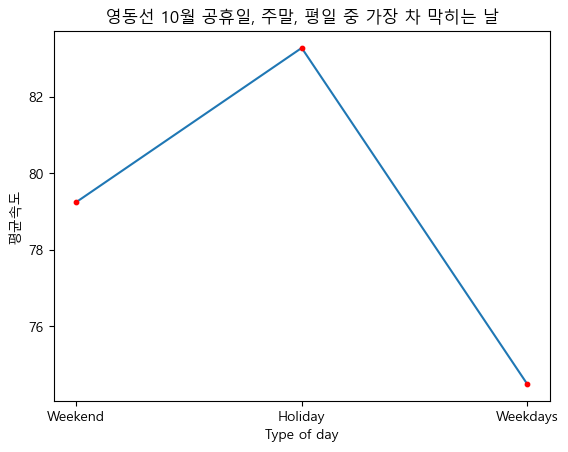

In [16]:
# <명제3> 공휴일과 주말은 평일보다 차가 안 막힐 것이다

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

df = pd.read_excel('10월_상행_가공\\10월_평일_공휴일_주말.xlsx')

AvgSpeed = np.array(df['평균속도'])
Type = np.array(df['요일'])
plt.plot(Type, AvgSpeed)
plt.title('영동선 10월 공휴일, 주말, 평일 중 가장 차 막히는 날')
plt.xlabel('Type of day')
plt.ylabel('평균속도')
plt.scatter(Type, AvgSpeed, color='red', s= 10, zorder=5)
plt.show()

<Figure size 1000x600 with 0 Axes>

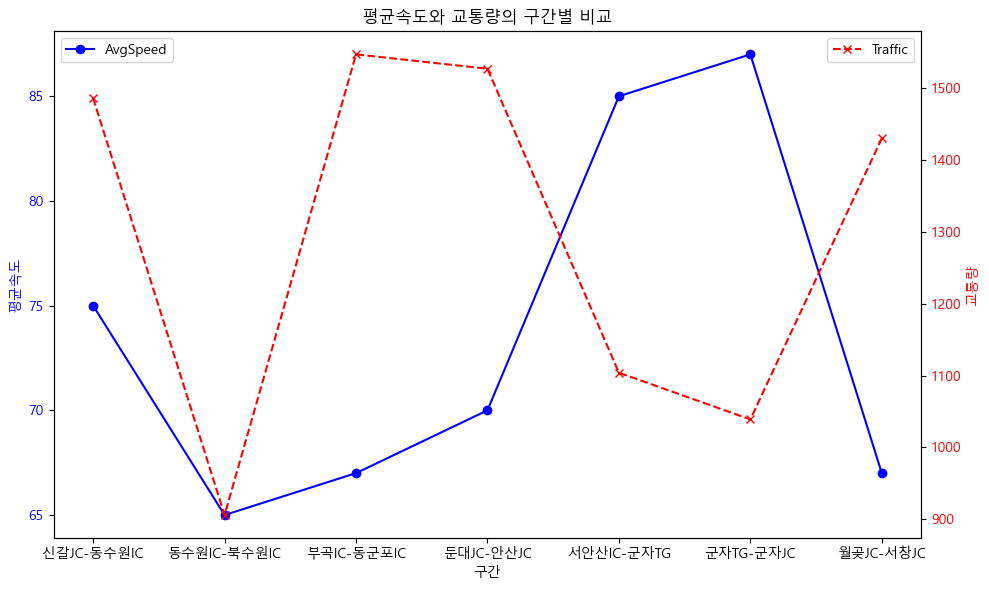

In [17]:
# <명제4> 교통량이 많으면 차도 막힐 것이다. <구간별 비교>

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

df = pd.read_excel('10월_교통량_가공\\구간별_교통량_속도.xlsx')

AvgSpeed = np.array(df['평균속도'])
Traffic = np.array(df['교통량'])
section = np.array(df['구간'])

plt.figure(figsize=(10, 6))

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(section, AvgSpeed, label='AvgSpeed', color='blue', linestyle='-', marker='o')
ax1.set_xlabel('구간')
ax1.set_ylabel('평균속도', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()

ax2.plot(section, Traffic, label='Traffic', color='red', linestyle='--', marker='x')
ax2.set_ylabel('교통량', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xticks(section)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('평균속도와 교통량의 구간별 비교')

plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

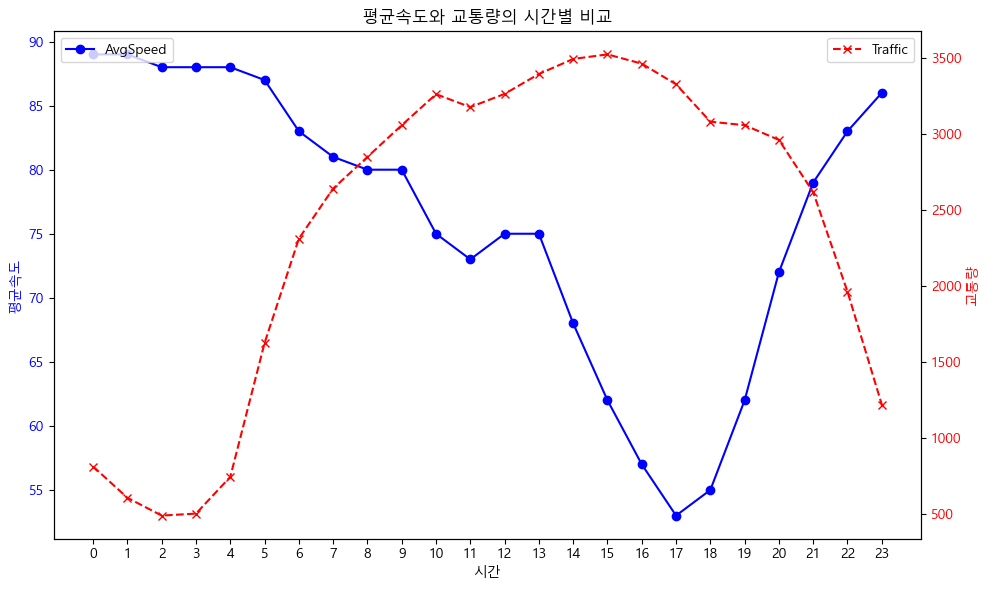

In [18]:
# <명제4> 교통량이 많으면 차도 막힐 것이다. <시간별 비교>

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

df = pd.read_excel('10월_교통량_가공\\시간별_교통량_속도.xlsx')

AvgSpeed = np.array(df['평균속도'])
Traffic = np.array(df['교통량'])
time = np.array(df['시간'])

plt.figure(figsize=(10, 6))

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(time, AvgSpeed, label='AvgSpeed', color='blue', linestyle='-', marker='o')
ax1.set_xlabel('시간')
ax1.set_ylabel('평균속도', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()

ax2.plot(time, Traffic, label='Traffic', color='red', linestyle='--', marker='x')
ax2.set_ylabel('교통량', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xticks(time)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('평균속도와 교통량의 시간별 비교')

plt.tight_layout()
plt.show()

## (6) 결론: <br>
 
 **확인점1**에서는 영동선 하행구간(서창JC -> 신갈JC)에서 가장 차가 막히는 구간을 확인하고자 하였다.<br>
 그 결과 확인점(1) 그래프에서와 같이 동군포IC ~ 부곡IC 가 15일, 군포IC ~ 동군포 IC가 15일, 서안산IC 안산IC가 1일로 동군포IC ~ 부곡IC와 군포IC ~ 동군포 IC가 영동선 하행에서 가장 막힌 구간인 것을 확인할 수 있었다.<br> 
 이 두 구간에 대한 특징으로는 모두 차선이 4차선에서 3차선으로 좁아지는 구간이라는 점이다.<br>

 **확인점2**에서는 영동선 상행구간(신갈JC -> 서창JC)에서 가장 차가 막히는 구간을 확인하고자 하였다.<br> 
 그 결과 동수원IC ~ 북수원IC가 21일, 부곡IC ~ 동군포IC가 5일, 월곶JC ~ 서창JC 2일, 둔대JC ~ 안산JC 2일, 동군포IC ~ 군포IC 1일로 나왔다.<br> 
 따라서 10월달 중 가장 자주 막힌 구간은 동수원IC ~ 북수원IC 구간이라는 것을 확인할 수 있었다.<br> 
 이 구간은 사실 좁아지는 차선도 아닌데 가장 자주 막힌 구간으로 나타났다.<br> 
 따라서 차량이 가장 많이 유입되는 구간임을 유추해볼 수 있다.<br>

 **확인점3**에서는 영동선 하행구간에서 가장 차가 막히는 시간대를 확인하고자 하였다.<br> 
 그 결과로 그래프에서와 같이 평균속도가 가장 낮은 시간대인 10시가 가장 차가 막히는 시간대임을 확인할 수 있었다.<br>

 **확인점4**에서는 영동선 상행구간에서 가장 차가 막히는 시간대를 확인하고자 하였다.<br> 
 그 결과로 그래프에서와 같이 평균속도가 가장 낮은 시간대인 17시가 가장 차가 막히는 시간대임을 확인할 수 있었다.<br>

 **명제1**에서는 영동선 하행구간 출근시간대(오전6시~9시)는 월요일이 가장 차가 막힐 것이다라는 명제를 세웠고 실제로 데이터 분석 결과와 일치하는지 알아보고자 하였다.<br> 
 그 결과로 그래프에서와 같이 10월달 중 월요일이 출근시간대에 평균속도가 가장 낮은 것을 확인할 수 있었다.<br> 
 따라서 명제1이 증명되었음을 알 수 있었다.<br>

 **명제2**에서는 영동선 상행구간 퇴근시간대(오후4시~7시)는 금요일이 가장 차가 막힐 것이다라는 명제를 세웠고 이에 대한 데이터 분석 결과가 일치하는지 알아보고자 하였다.<br> 
 그 결과로 그래프에서와 같이 10월달 중 금요일이 퇴근시간대에 평균속도가 가장 낮은 것을 확인할 수 있었다.<br> 
 따라서 명제2가 증명되었음을 알 수 있었다.<br>

 **명제3**에서는 공휴일과 주말은 평일보다 차가 안 막힐 것이다라는 명제를 세웠고 실제로 10월 중 공휴일(국군의 날, 개천절, 한글날)과 주말 평일 중 가장 차가 막히는 날을 구해봤다.<br> 
 그 결과로 그래프에서와 같이 Weekdays, 즉, 평일이 가장 평균속도가 낮게 나와 명제3이 증명되었음을 알 수 있었다.<br>

 **명제4**에서는 교통량이 많으면 차도 막힐 것이다라는 명제를 세웠고 이를 증명하기 위해 교통량과 평균속도를 구간별과 시간별 두 가지 그래프를 만들어 비교해봤다.<br> 
 그 결과로 구간별 그래프에서는 신갈JC-동수원 구간과 동수원IC-북수원IC 구간을 제외하고 나머지 구간에 대해서는 평균속도와 교통량이 서로 반비례하는 관계를 잘 보여줬다.<br> 
 시간별 그래프에서도 전반적으로 평균속도와 교통량 두 그래프 간의 위상을 보면 반비례 관계에 있음을 직관적으로 확인할 수 있다.<br> 
 따라서 전반적인 두 변인간의 반비례 관계는 확인할 수 있었으나 교통사고와 같은 여러 변인에 대한 통제가 이뤄지지 않았기에 일관적인 그래프 양상이 나타나지 않았던 것 같다.<br>


## (7) 참고문헌: <br>

https://www.w3schools.com/python/pandas/default.asp <br>

https://velog.io/@euisuk-chung/%ED%8C%8C%EC%9D%B4%EC%8D%AC-%EC%8B%9C%EA%B0%81%ED%99%94-%EB%A7%88%EC%8A%A4%ED%84%B0%ED%95%98%EA%B8%B0-Pandas <br>

https://wikidocs.net/book/7188 [Python 완전정복 시리즈] 2편 : Pandas DataFrame 완전정복 <br>

https://with-kwang.tistory.com/80 <br>

https://wikidocs.net/216529 <br>

https://numpy.org/doc/stable/user/absolute_beginners.html <br>

https://www.w3schools.com/python/numpy/default.asp <br>


## (8) 별첨: <br>

 하기 이름의 폴더에 첨부하였다. <br>

 영동선_10월_상행 <br>

 영동선_10월_상행_교통량<br>

 영동선_10월_하행<br>

## (9) 별첨: <br>

 하기 이름의 폴더에 첨부하였다.<br>

 10월_교통량_가공<br>

 10월_상행_가공<br>

 10월_하행_가공<br>

## (10) 별첨: <br>
 Final_Term_source_2020104218.ipynb <br>

 Term_module.py <br>

 Term_Project_2020104218.ipynb에서 (5)분석 결과 도출에 사용된 코드 <br> 